# PPO

In [6]:
import gymnasium as gym
import numpy as np

import os
import random

import torch
import torch.nn as nn
from torch.distributions.categorical import Categorical

In [132]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, checkpoint_dir = "./", file_name = "policy.pth") -> None:
        super().__init__()

        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        self.net = nn.Sequential(
            nn.Linear(state_dim, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, action_dim)        
        )

        self.checkpoint_dir = os.path.join(checkpoint_dir, file_name)

        self.to(self.device)

    def forward(self, x):
        return self.net(x)

    def save_checkpoint(self):
        os.makedirs(os.path.dirname(self.checkpoint_dir), exist_ok=True)
        torch.save(self.state_dict(), self.checkpoint_dir)

    def load_checkpoint(self):
        self.load_state_dict(torch.load(self.checkpoint_dir))
        self.net.to(self.device)



class ValueNetwork(nn.Module):
    def __init__(self, state_dim, checkpoint_dir = "./", file_name = "value.pth") -> None:
        super().__init__()

        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        self.net = nn.Sequential(
            nn.Linear(state_dim, 100),
            nn.ReLU(),
            nn.Linear(100, 10),
            nn.ReLU(),
            nn.Linear(10, 1)
        )

        self.checkpoint_dir = os.path.join(checkpoint_dir, file_name)

        self.to(self.device)


    def forward(self, x):
        return self.net(x)

    def save_checkpoint(self):
            os.makedirs(os.path.dirname(self.checkpoint_dir), exist_ok=True)
            torch.save(self.state_dict(), self.checkpoint_dir)
    
    def load_checkpoint(self):
        self.load_state_dict(torch.load(self.checkpoint_dir))
        self.net.to(self.device)

In [141]:
class RollOutMemory:
    def __init__(self) -> None:
        self.states = []
        self.actions = []
        self.rewards = []
        self.next_states = []
        self.values = []
        self.old_log_probs = []
        self.dones = []
        self.returns = []
        self.advantages = []

    def save(self, state, action, reward, next_state, value, old_log_prob, done):
        self.states.append(state)
        self.actions.append(action)
        self.rewards.append(reward)
        self.next_states.append(next_state)
        self.values.append(value)
        self.old_log_probs.append(old_log_prob)
        self.dones.append(done)

    def clear(self):
        self.states.clear()
        self.actions.clear()
        self.rewards.clear()
        self.next_states.clear()
        self.values.clear()
        self.old_log_probs.clear()
        self.dones.clear()
        self.advantages.clear()
        self.returns.clear()

    def sample(self, batch_size):
        n = len(self.rewards)
        indices = torch.randperm(n)
        for start in range(0, n, batch_size):
            batch_indices = indices[start:start+batch_size]
            yield (
                [self.states[i] for i in batch_indices],
                [self.actions[i] for i in batch_indices],
                [self.old_log_probs[i] for i in batch_indices],
                [self.advantages[i] for i in batch_indices],
                [self.returns[i] for i in batch_indices],
            )

In [ ]:
class PPOAgent:
    def __init__(self,env_name,  state_dim, action_dim, policy_checkpoint_dir = "./", value_checkpoint_dir = "./") -> None:
        self.policy = PolicyNetwork(state_dim, action_dim, policy_checkpoint_dir)
        self.value = ValueNetwork(state_dim, value_checkpoint_dir)
        self.rollout_memory = RollOutMemory()
        self.env_name = env_name  # used for initilizing the environment in render_mode = "human"
        self.env = gym.make(env_name)
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        self.critic_criterion = nn.functional.mse_loss
        
        self.policy_optimizer = torch.optim.Adam(self.policy.parameters(), lr=3e-4)
        self.value_optimizer = torch.optim.Adam(self.value.parameters(), lr=1e-3)

        

    def save_agent(self):
        self.policy.save_checkpoint()
        self.value.save_checkpoint()

    def load_agent(self):
        self.policy.load_checkpoint()
        self.value.load_checkpoint()

    def act(self):
        self.env = gym.make(self.env_name, render_mode = "human")
        done = False
        total_reward = 0.0
        observation, info = self.env.reset()
        while not done:
            action = self.policy(
                torch.tensor(observation, device=self.device)
            ).argmax().item()

            observation, reward, terminated, truncated, info = self.env.step(action)
            done = terminated or truncated
            total_reward +=  float(reward)
        self.env.close()

        return total_reward




    def train(self, discount_factor = 0.99, gae_factor = 0.95, epsilon = 0.2,  rollouts = 2048, training_iters = 10, batch_size = 64, critic_factor = 0.5, entropy_factor = 0.01, ppo_iters = 50):
        losses = []

        for i in range(ppo_iters):
            observation, info = self.env.reset()

            # collecting rollout
            for t in range(rollouts):
                observation = torch.as_tensor(observation, device=self.device)

                with torch.no_grad():
                    actions_logits = self.policy(observation)
                    actions_dist = Categorical(logits=actions_logits)
                    action = actions_dist.sample()
                    action_log_prob = actions_dist.log_prob(action)

                    value = self.value(observation).squeeze()  # squeezing it becuase it will cause dimension mismatch in advantage calculation

                    new_observation, reward, terminated, truncated, info = self.env.step(action.item())

                    done = terminated or truncated

                    self.rollout_memory.save(observation, action, reward, new_observation, value, action_log_prob, done)

                    if done:
                        observation, info = self.env.reset()
                    else:
                        observation = new_observation
            # end rollout loop


            # GAE Calculation

            with torch.no_grad():
                advantage = 0.0
                for t in reversed(range(rollouts)):
                    rt = self.rollout_memory.rewards[t]
                    vt = self.rollout_memory.values[t]
                    done = self.rollout_memory.dones[t]

                    if(t == (rollouts -1)):
                        vtnext = self.value(
                            torch.tensor(
                                self.rollout_memory.next_states[t],
                                device=self.device,
                                requires_grad=False
                            )
                        ).squeeze()
                    else:
                        vtnext = self.rollout_memory.values[t+1]

                    delta = rt + discount_factor * (1 - float(done)) * vtnext - vt

                    advantage = delta + discount_factor * gae_factor  * (1 - float(done)) *  advantage
 
                    self.rollout_memory.advantages.append(advantage)

                    self.rollout_memory.returns.append(advantage + vt)

                self.rollout_memory.advantages.reverse()
                self.rollout_memory.returns.reverse()
            # end GAE calculation
            

            #PPO optimization
            for k in range(training_iters):
                loss_per_iteration = 0.0
                for batch in self.rollout_memory.sample(batch_size):
                    states, actions, old_log_probs, advantages, returns = batch

                    states = torch.stack(states)
                    actions = torch.stack(actions)
                    old_log_probs = torch.stack(old_log_probs)

                    advantages = torch.stack(advantages)
                    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

                    returns = torch.stack(returns)

                    logits = self.policy(states)
                    dist = Categorical(logits=logits)
                    log_probs = dist.log_prob(actions)

                    


                    ratio = torch.exp(log_probs - old_log_probs)

                    L_1 = advantages * ratio
                    L_2 = torch.clip(ratio, 1-epsilon, 1+epsilon) * advantages

                    actor_loss = (
                        torch.min(L_1, L_2)
                    ).mean()

                    critic_loss = self.critic_criterion(
                        self.value(states).squeeze(), returns
                    )

                    entropy = dist.entropy().mean()

                    total_loss = (
                        - actor_loss + critic_factor * critic_loss - entropy_factor * entropy
                    )


                    self.policy_optimizer.zero_grad()
                    self.value_optimizer.zero_grad()

                    total_loss.backward()

                    self.policy_optimizer.step()
                    self.value_optimizer.step()

                    loss_per_iteration += total_loss.item()
                
                
                loss_per_iteration /= ( rollouts // batch_size )
                    
                losses.append(loss_per_iteration)
                print(f"loss: {loss_per_iteration}")

                
                

            print(f"PPO iter: {i} ")

            self.rollout_memory.clear()

            self.save_agent()

        return losses

                    
            
        

In [150]:
agent = PPOAgent("LunarLander-v3", 8, 4)

In [151]:
losses = agent.train(rollouts=2048, batch_size=64)

loss: 1135.4009799957275
loss: 1119.4681224822998
loss: 1078.9128189086914
loss: 984.1907587051392
loss: 824.6324758529663
loss: 638.641863822937
loss: 510.43984603881836
loss: 459.54828786849976
loss: 432.19188117980957
loss: 407.73157501220703
PPO iter: 0 
loss: 271.50185441970825
loss: 175.9865665435791
loss: 165.6982786655426
loss: 159.64861345291138
loss: 155.29021573066711
loss: 152.748450756073
loss: 150.36703729629517
loss: 148.51190209388733
loss: 147.3165373802185
loss: 146.2807537317276
PPO iter: 1 
loss: 311.58818006515503
loss: 274.9404556751251
loss: 265.16888546943665
loss: 258.905398607254
loss: 254.27957797050476
loss: 250.08796167373657
loss: 246.2025773525238
loss: 243.1195089817047
loss: 240.03761553764343
loss: 237.0903356075287
PPO iter: 2 
loss: 185.17312908172607
loss: 177.78541588783264
loss: 174.93987441062927
loss: 172.98794412612915
loss: 170.9452395439148
loss: 169.44642877578735
loss: 167.87984108924866
loss: 166.1207628250122
loss: 164.66860723495483
loss

In [154]:
agent.act()

-35.65285698650383

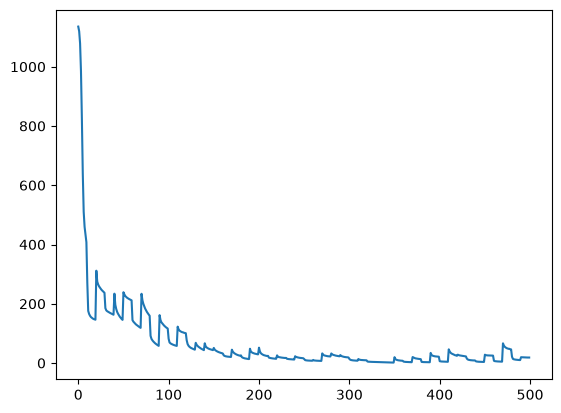

In [152]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.show()

In [6]:
a

[4, 3, 2, 1, 0]